# Day 09. Exercise 03
# Ensembles

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, PredefinedSplit
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, BaggingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
import itertools
import joblib
import warnings
import matplotlib.pyplot as plt

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
warnings.filterwarnings('ignore')

## 1. Preprocessing

1. Create the same dataframe as in the previous exercise.
2. Using `train_test_split` with parameters `test_size=0.2`, `random_state=21` get `X_train`, `y_train`, `X_test`, `y_test` and then get `X_train`, `y_train`, `X_valid`, `y_valid` from the previous `X_train`, `y_train`. Use the additional parameter `stratify`.

In [3]:
df = pd.read_csv('../data/day-of-week-not-scaled.csv')
day_of_week = pd.read_csv('../data/dayofweek.csv', usecols=['dayofweek'])
df = pd.concat([day_of_week, df], axis=1)
df.head(1)

,dayofweek,numTrials,hour,uid_user_0,uid_user_1,uid_user_10,uid_user_11,uid_user_12,uid_user_13,uid_user_14,uid_user_15,uid_user_16,uid_user_17,uid_user_18,uid_user_19,uid_user_2,uid_user_20,uid_user_21,uid_user_22,uid_user_23,uid_user_24,uid_user_25,uid_user_26,uid_user_27,uid_user_28,uid_user_29,uid_user_3,uid_user_30,uid_user_31,uid_user_4,uid_user_6,uid_user_7,uid_user_8,labname_code_rvw,labname_lab02,labname_lab03,labname_lab03s,labname_lab05s,labname_laba04,labname_laba04s,labname_laba05,labname_laba06,labname_laba06s,labname_project1
0,4,1,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [4]:
RANDOM_STATE=21
X = df.drop(columns=['dayofweek'])
y = df['dayofweek']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train)

## 2. Individual classifiers

1. Train SVM, decision tree and random forest again with the best parameters that you got from the 01 exercise with `random_state=21` for all of them.
2. Evaluate `accuracy`, `precision`, and `recall` for them on the validation set.
3. The result of each cell of the section should look like this:

```
accuracy is 0.87778
precision is 0.88162
recall is 0.87778
```

In [5]:
svc = SVC(
    C=10,
    class_weight=None,
    gamma='auto',
    kernel='rbf',
    random_state=RANDOM_STATE,
    probability=True
)

tree = DecisionTreeClassifier(
    class_weight='balanced',
    criterion='gini',
    max_depth=21,
    random_state=RANDOM_STATE,
)

forest = RandomForestClassifier(
    class_weight='balanced',
    criterion='entropy',
    max_depth=24,
    n_estimators=100,
    random_state=RANDOM_STATE
)

svc.fit(X_train, y_train)
tree.fit(X_train, y_train)
forest.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=24, random_state=21)

In [6]:
def print_metrics(model, X=X_valid, y=y_valid):
    y_pred = model.predict(X)
    
    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred, average='weighted')
    recall = recall_score(y, y_pred, average='weighted')

    print(f'accuracy is {accuracy:.5}')
    print(f'precision is {precision:.5}')
    print(f'recall is {recall:.5}')

    return accuracy, precision, recall

In [7]:
print('===Метрики SVC===')
print_metrics(svc);
print('\n===Метрики DesicionTree===')
print_metrics(tree);
print('\n===Метрики RandomForest===')
print_metrics(forest);

===Метрики SVC===
accuracy is 0.87778
precision is 0.88162
recall is 0.87778

===Метрики DesicionTree===
accuracy is 0.86667
precision is 0.8717
recall is 0.86667

===Метрики RandomForest===
accuracy is 0.8963
precision is 0.89698
recall is 0.8963


## 3. Voting classifiers

1. Using `VotingClassifier` and the three models that you have just trained, calculate the `accuracy`, `precision`, and `recall` on the validation set.
2. Play with the other parameteres.
3. Calculate the `accuracy`, `precision` and `recall` on the test set for the model with the best weights in terms of accuracy (if there are several of them with equal values, choose the one with the higher precision).

In [8]:
voting = VotingClassifier(
    estimators=[('svc', svc), ('tree', tree), ('forest', forest)]
)
voting.fit(X_train, y_train)

print('\n===Метрики VotingClassifier===')
print_metrics(voting);


===Метрики VotingClassifier===
accuracy is 0.9
precision is 0.89993
recall is 0.9


In [9]:
X_combined = pd.concat([X_train, X_valid])
y_combined = pd.concat([y_train, y_valid])

split_index = [-1] * len(X_train) + [0] * len(X_valid)
pds = PredefinedSplit(test_fold=split_index)

In [10]:
param_grid = {
    'voting': ['hard', 'soft'],
    'weights': list(itertools.product(range(1, 5), repeat=3))
}

grid_search = GridSearchCV(
    estimator=voting,
    param_grid=param_grid,
    scoring=['accuracy', 'precision_weighted'],
    refit=False,
    cv=pds,
    n_jobs=-1
)
grid_search.fit(X_combined, y_combined)

GridSearchCV(cv=PredefinedSplit(test_fold=array([-1, -1, ...,  0,  0])),
             estimator=VotingClassifier(estimators=[('svc',
                                                     SVC(C=10, gamma='auto',
                                                         probability=True,
                                                         random_state=21)),
                                                    ('tree',
                                                     DecisionTreeClassifier(class_weight='balanced',
                                                                            max_depth=21,
                                                                            random_state=21)),
                                                    ('forest',
                                                     RandomForestClassifier(class_weight='balanced',
                                                                            criterion='entropy',
                               

In [11]:
results_df = pd.DataFrame(grid_search.cv_results_)
results_df_sorted = results_df.sort_values(
    ['mean_test_accuracy', 'mean_test_precision_weighted'],
    ascending=[False, False]
)

best_row = results_df_sorted.iloc[0]
best_params = best_row['params']

print('===Лучшие параметры VotingClassifier на валидации===')
print(f"params: {best_params}")
print(f"accuracy is {best_row['mean_test_accuracy']:.5}")
print(f"precision is {best_row['mean_test_precision_weighted']:.5}")

===Лучшие параметры VotingClassifier на валидации===
params: {'voting': 'soft', 'weights': (4, 1, 4)}
accuracy is 0.91111
precision is 0.91288


In [12]:
best_voting = VotingClassifier(
    estimators=[('svc', svc), ('tree', tree), ('forest', forest)],
    voting=best_params['voting'],
    weights=best_params['weights']
)
best_voting.fit(X_train, y_train)

VotingClassifier(estimators=[('svc',
                              SVC(C=10, gamma='auto', probability=True,
                                  random_state=21)),
                             ('tree',
                              DecisionTreeClassifier(class_weight='balanced',
                                                     max_depth=21,
                                                     random_state=21)),
                             ('forest',
                              RandomForestClassifier(class_weight='balanced',
                                                     criterion='entropy',
                                                     max_depth=24,
                                                     random_state=21))],
                 voting='soft', weights=(4, 1, 4))

In [13]:
print('===Метрики на валидации===')
print_metrics(best_voting);
print('===Метрики на тесте===')
print_metrics(best_voting, X_test, y_test);

===Метрики на валидации===
accuracy is 0.91111
precision is 0.91288
recall is 0.91111
===Метрики на тесте===
accuracy is 0.90533
precision is 0.90881
recall is 0.90533


## 4. Bagging classifiers

1. Using `BaggingClassifier` and `SVM` with the best parameters create an ensemble, try different values of the `n_estimators`, use `random_state=21`.
2. Play with the other parameters.
3. Calculate the `accuracy`, `precision`, and `recall` for the model with the best parameters (in terms of accuracy) on the test set (if there are several of them with equal values, choose the one with the higher precision)

In [14]:
X_combined = pd.concat([X_train, X_valid])
y_combined = pd.concat([y_train, y_valid])
split_index = [-1] * len(X_train) + [0] * len(X_valid)
pds = PredefinedSplit(test_fold=split_index)

bagging = BaggingClassifier(
    base_estimator=svc,
    random_state=RANDOM_STATE
)

In [15]:
param_grid = {
    'n_estimators': [1, 5, 10, 20, 30, 50, 75, 100],
    'max_samples': [0.5, 0.7, 1.0],
    'max_features': [0.5, 0.7, 1.0],
    'bootstrap': [True]
}

grid_search = GridSearchCV(
    estimator=bagging,
    param_grid=param_grid,
    scoring=['accuracy', 'precision_weighted'],
    refit=False,
    cv=pds,
    n_jobs=-1
)
grid_search.fit(X_combined, y_combined)

GridSearchCV(cv=PredefinedSplit(test_fold=array([-1, -1, ...,  0,  0])),
             estimator=BaggingClassifier(base_estimator=SVC(C=10, gamma='auto',
                                                            probability=True,
                                                            random_state=21),
                                         random_state=21),
             n_jobs=-1,
             param_grid={'bootstrap': [True], 'max_features': [0.5, 0.7, 1.0],
                         'max_samples': [0.5, 0.7, 1.0],
                         'n_estimators': [1, 5, 10, 20, 30, 50, 75, 100]},
             refit=False, scoring=['accuracy', 'precision_weighted'])

In [16]:
results_df = pd.DataFrame(grid_search.cv_results_)
results_df_sorted = results_df.sort_values(
    ['mean_test_accuracy', 'mean_test_precision_weighted'],
    ascending=[False, False]
)

best_row = results_df_sorted.iloc[0]
best_params = best_row['params']

print('===Лучшие параметры BaggingClassifier на валидации===')
print(f"params: {best_params}")
print(f"accuracy is {best_row['mean_test_accuracy']:.5}")
print(f"precision is {best_row['mean_test_precision_weighted']:.5}")

===Лучшие параметры BaggingClassifier на валидации===
params: {'bootstrap': True, 'max_features': 1.0, 'max_samples': 1.0, 'n_estimators': 30}
accuracy is 0.88889
precision is 0.89718


In [17]:
best_bagging = BaggingClassifier(
    base_estimator=svc,
    random_state=RANDOM_STATE,
    **best_params
)
best_bagging.fit(X_train, y_train)

BaggingClassifier(base_estimator=SVC(C=10, gamma='auto', probability=True,
                                     random_state=21),
                  n_estimators=30, random_state=21)

In [18]:
print('===Метрики на валидации===')
print_metrics(best_bagging);
print('===Метрики на тесте===')
print_metrics(best_bagging, X_test, y_test);

===Метрики на валидации===
accuracy is 0.88889
precision is 0.89718
recall is 0.88889
===Метрики на тесте===
accuracy is 0.87278
precision is 0.8784
recall is 0.87278


accuracy is 0.88889
precision is 0.89378
recall is 0.88889
===Метрики на тесте===


accuracy is 0.88757
precision is 0.88906
recall is 0.88757


## 5. Stacking classifiers

1. To achieve reproducibility in this case you will have to create an object of cross-validation generator: `StratifiedKFold(n_splits=n, shuffle=True, random_state=21)`, where `n` you will try to optimize (the details are below).
2. Using `StackingClassifier` and the three models that you have recently trained, calculate the `accuracy`, `precision` and `recall` on the validation set, try different values of `n_splits` `[2, 3, 4, 5, 6, 7]` in the cross-validation generator and parameter `passthrough` in the classifier itself,
3. Calculate the `accuracy`, `precision`, and `recall` for the model with the best parameters (in terms of accuracy) on the test set (if there are several of them with equal values, choose the one with the higher precision). Use `final_estimator=LogisticRegression(solver='liblinear')`.

In [19]:
n_splits_options = [2, 3, 4, 5, 6, 7]
passthrough_options = [True, False]

results = []

for n_splits in n_splits_options:
    for passthrough in passthrough_options:
        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
        
        stacking = StackingClassifier(
            estimators=[('svc', svc), ('tree', tree), ('forest', forest)],
            final_estimator=OneVsRestClassifier(LogisticRegression(solver='liblinear')),
            cv=cv,
            passthrough=passthrough
        )
        stacking.fit(X_train, y_train)
        
        print(f'n_splits={n_splits}, passthrough={passthrough}')
        accuracy, precision, recall = print_metrics(stacking)
        print()
        
        results.append({
            'n_splits': n_splits,
            'passthrough': passthrough,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'model': stacking
        })

n_splits=2, passthrough=True
accuracy is 0.9037
precision is 0.90619
recall is 0.9037

n_splits=2, passthrough=False
accuracy is 0.8963
precision is 0.89678
recall is 0.8963

n_splits=3, passthrough=True
accuracy is 0.9037
precision is 0.90632
recall is 0.9037

n_splits=3, passthrough=False
accuracy is 0.8963
precision is 0.89759
recall is 0.8963

n_splits=4, passthrough=True
accuracy is 0.91111
precision is 0.91327
recall is 0.91111

n_splits=4, passthrough=False
accuracy is 0.9037
precision is 0.9057
recall is 0.9037

n_splits=5, passthrough=True
accuracy is 0.9
precision is 0.90217
recall is 0.9

n_splits=5, passthrough=False
accuracy is 0.9
precision is 0.90056
recall is 0.9

n_splits=6, passthrough=True
accuracy is 0.9037
precision is 0.9045
recall is 0.9037

n_splits=6, passthrough=False
accuracy is 0.9037
precision is 0.90436
recall is 0.9037

n_splits=7, passthrough=True
accuracy is 0.9037
precision is 0.9064
recall is 0.9037

n_splits=7, passthrough=False
accuracy is 0.9037
pr

n_splits=2, passthrough=False
accuracy is 0.89259
precision is 0.89371
recall is 0.89259



n_splits=3, passthrough=True
accuracy is 0.8963
precision is 0.89841
recall is 0.8963



n_splits=3, passthrough=False
accuracy is 0.9
precision is 0.90132
recall is 0.9



n_splits=4, passthrough=True
accuracy is 0.9037
precision is 0.90642
recall is 0.9037



...

n_splits=5, passthrough=False
accuracy is 0.91481
precision is 0.91748
recall is 0.91481



n_splits=6, passthrough=True
accuracy is 0.9037
precision is 0.90596
recall is 0.9037



n_splits=6, passthrough=False
accuracy is 0.9037
precision is 0.90482
recall is 0.9037



n_splits=7, passthrough=True
accuracy is 0.90741
precision is 0.90902
recall is 0.90741



n_splits=7, passthrough=False
accuracy is 0.9
precision is 0.90138
recall is 0.9



In [20]:
best_result = max(results, key=lambda r: (r['accuracy'], r['precision']))

print('===Лучшие параметры StackingClassifier===')
print(f"n_splits={best_result['n_splits']}, passthrough={best_result['passthrough']}")

best_stacking = best_result['model']

print('===Метрики на валидации===')
print_metrics(best_stacking);
print('===Метрики на тесте===')
print_metrics(best_stacking, X_test, y_test);

===Лучшие параметры StackingClassifier===
n_splits=4, passthrough=True
===Метрики на валидации===
accuracy is 0.91111
precision is 0.91327
recall is 0.91111
===Метрики на тесте===
accuracy is 0.90533
precision is 0.90844
recall is 0.90533


## 6. Predictions

1. Choose the best model in terms of accuracy (if there are several of them with equal values, choose the one with the higher precision).
2. Analyze: for which weekday your model makes the most errors (in % of the total number of samples of that class in your full dataset), for which labname and for which users.
3. Save the model.

Лучшая модель - **VotingClassifier** (accuracy is 0.90533, precision is 0.90881, recall is 0.90533)

In [21]:
best_model = best_voting
y_pred_best = best_model.predict(X)

In [22]:
user_cols = [c for c in df.columns if c.startswith('uid_user_')]
labname_cols = [c for c in df.columns if c.startswith('labname_')]

df['user'] = df[user_cols].idxmax(axis=1)
df['labname'] = df[labname_cols].idxmax(axis=1)

errors = y.values != y_pred_best
error_idx = X.index[errors]

for col in ['dayofweek', 'labname', 'user']:
    err_counts = df.loc[error_idx, col].value_counts()
    total_counts = df[col].value_counts()
    rate = (err_counts / total_counts * 100).fillna(0)
    df[f'{col}_error_rate'] = df[col].map(rate).fillna(0)

In [23]:
weekday_summary = df[['dayofweek', 'dayofweek_error_rate']].drop_duplicates().sort_values('dayofweek_error_rate', ascending=False)
labname_summary = df[['labname', 'labname_error_rate']].drop_duplicates().sort_values('labname_error_rate', ascending=False)
user_summary = df[['user', 'user_error_rate']].drop_duplicates().sort_values('user_error_rate', ascending=False)

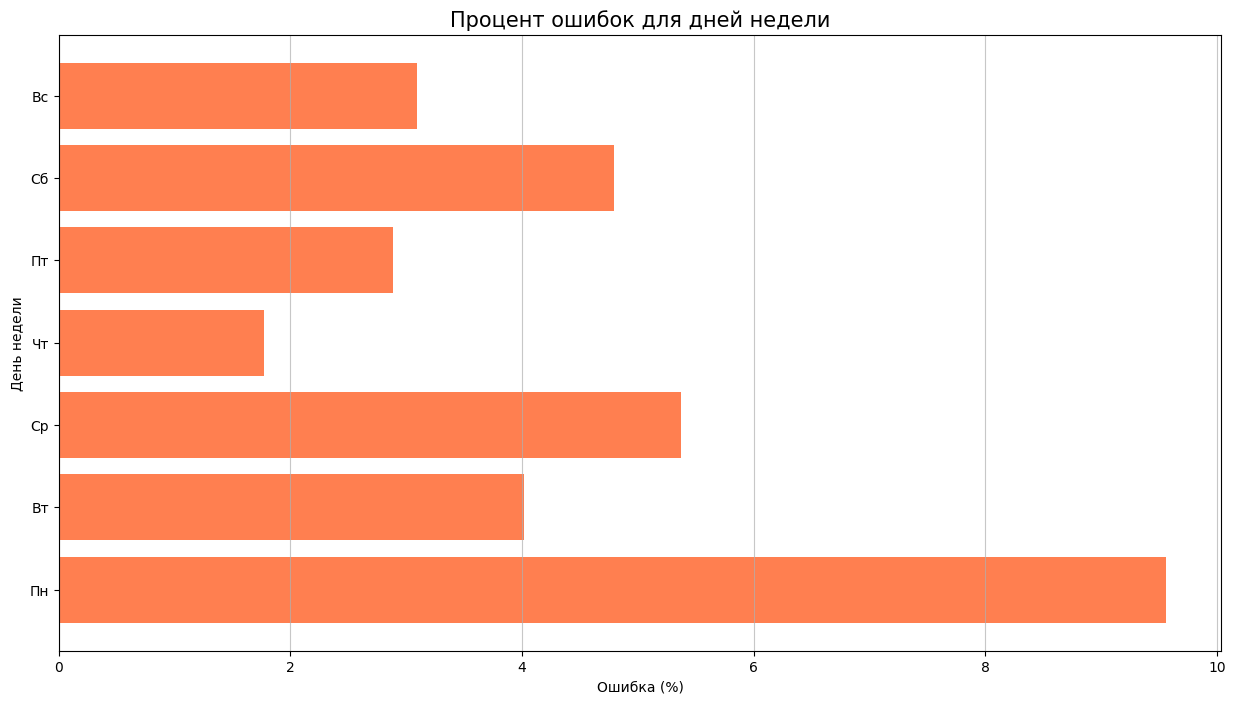

In [24]:
plt.figure(figsize=(15, 8))
plt.barh(
    weekday_summary['dayofweek'],
    weekday_summary['dayofweek_error_rate'],
    color='coral',
)
plt.grid(axis='x', alpha=0.7)
plt.xlabel('Ошибка (%)')
plt.ylabel('День недели')
plt.yticks(
    ticks=range(7),
    labels=['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс'],
    fontsize=10
)
plt.title('Процент ошибок для дней недели', fontsize=15)
plt.show()

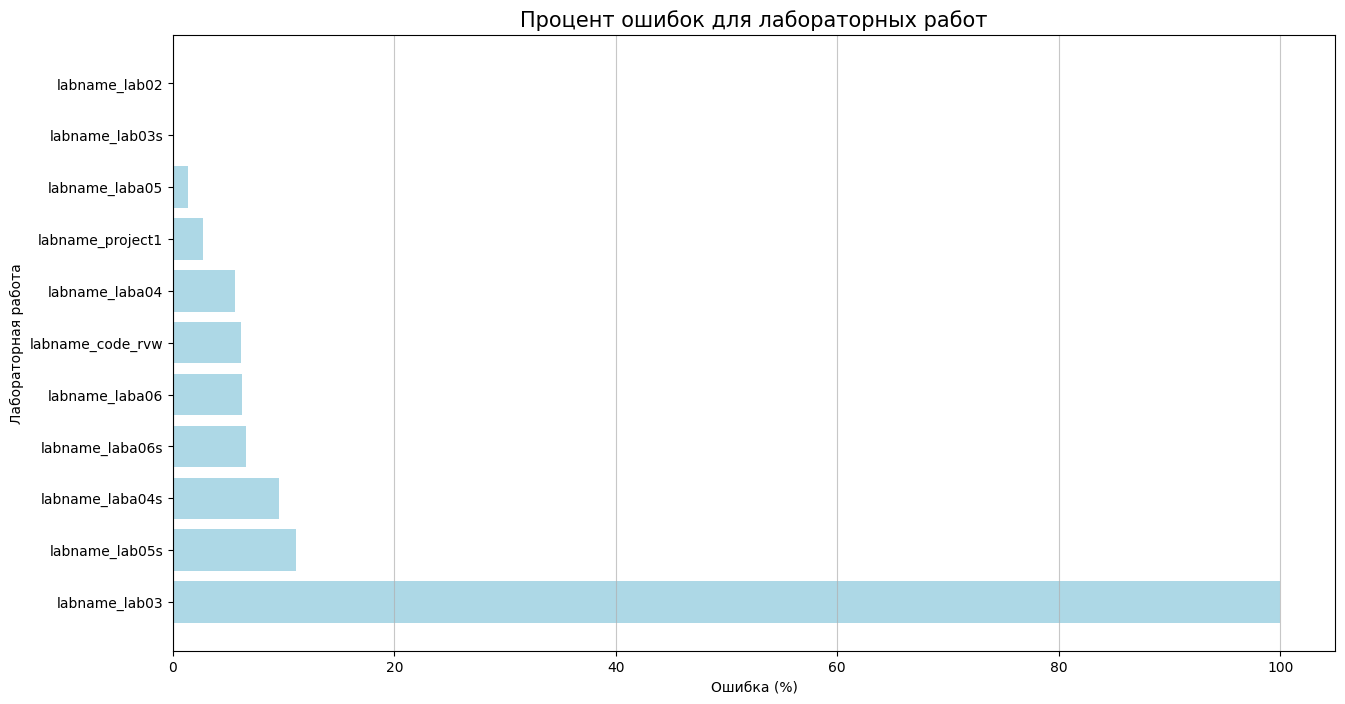

In [25]:
plt.figure(figsize=(15, 8))
plt.barh(
    labname_summary['labname'],
    labname_summary['labname_error_rate'],
    color='lightblue',
)
plt.grid(axis='x', alpha=0.7)
plt.xlabel('Ошибка (%)')
plt.ylabel('Лабораторная работа')
plt.title('Процент ошибок для лабораторных работ', fontsize=15)
plt.show()

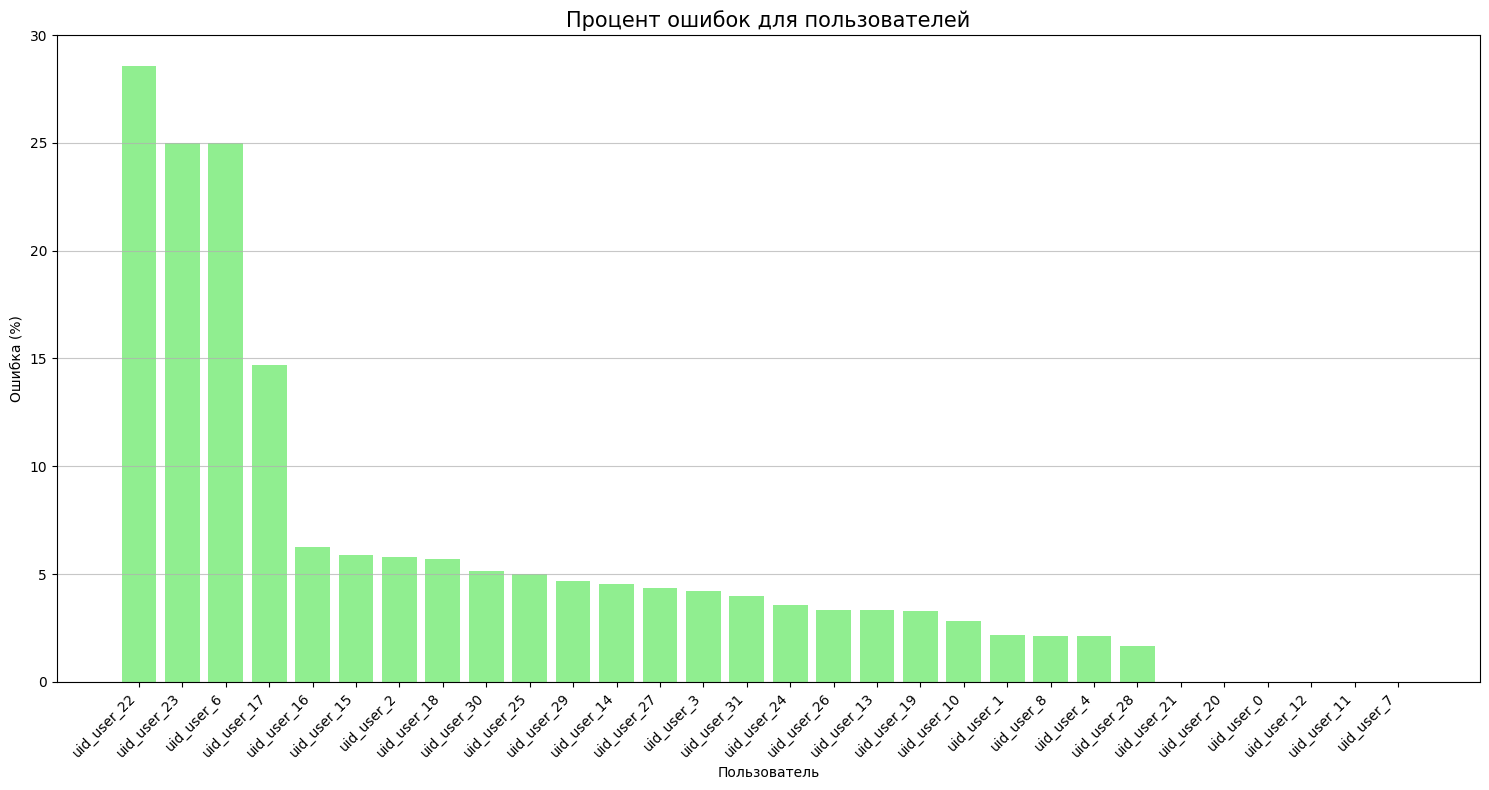

In [26]:
plt.figure(figsize=(15, 8))
plt.bar(
    user_summary['user'],
    user_summary['user_error_rate'],
    color='lightgreen'
)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.7) 
plt.xlabel('Пользователь')
plt.ylabel('Ошибка (%)')
plt.title('Процент ошибок для пользователей', fontsize=15)

plt.tight_layout()
plt.show()

In [27]:
joblib.dump(best_model, '../data/ex03.pkl')

['../data/ex03.pkl']